In [ ]:
from astroquery.ipac.ned import Ned

# Descarga los espectros (lista de HDUList)  
spectra_list = Ned.get_spectra("3c 273", show_progress=True)
print("Espectros descargados:", len(spectra_list))

# Guardado forzando ignore de violaciones FITS
for idx, hdulist in enumerate(spectra_list):
    fname = f"spectrum_{idx+1}.fits"
    # output_verify='ignore' omite errores por keywords no estándar
    hdulist.writeto(fname, overwrite=True, output_verify='ignore')
    print("Guardado:", fname)

Espectros descargados: 24


SIMPLE  =                    T  /  FITS STANDARD                                BITPIX  =                  -32  /  FITS BITS/PIXEL                              NAXIS   =                    1  /  NUMBER OF AXES                               NAXIS1  =                 1024  /                                               OBJECT  = 'PG 1226+02 = 3C 273 - Aperture 1'  /                                 ORIGIN  = 'KPNO-IRAF'  /                                                        DATE    = '21-01-92'  /                                                         IRAFNAME= '023z.imh'  /  NAME OF IRAF IMAGE FILE                                IRAF-MAX=           4.478000E3  /  DATA MAX                                     IRAF-MIN=           5.780000E2  /  DATA MIN                                     IRAF-B/P=                   32  /  DATA BITS/PIXEL                              IRAFTYPE= 'FLOATING'  /                                                         OBSERVAT= 'KPNO              ' / ORIGIN 

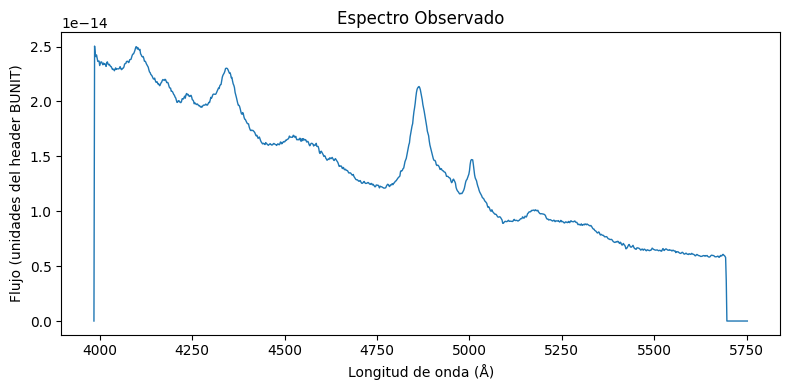

: 

In [ ]:
from astropy.io import fits             # para manejar FITS :contentReference[oaicite:6]{index=6}
import numpy as np
import matplotlib.pyplot as plt         # para graficar 

# 1) Abrir FITS
hdul = fits.open('spectrums NASA/spectrum_1.fits')     # abre el archivo :contentReference[oaicite:7]{index=7}
data = hdul[0].data                     # array de flujo de 1024 puntos :contentReference[oaicite:8]{index=8}
hdr  = hdul[0].header                   # header con WCS :contentReference[oaicite:9]{index=9}
print(hdr)

# 2) Leer parámetros WCS
naxis1 = hdr['NAXIS1']                  # número de píxeles espectrales :contentReference[oaicite:10]{index=10}
crval1 = hdr['CRVAL1']                  # valor de λ en píxel de referencia :contentReference[oaicite:11]{index=11}
cdelt1 = hdr['CDELT1']                  # paso en Å/píxel :contentReference[oaicite:12]{index=12}
crpix1 = hdr['CRPIX1']                  # píxel de referencia (1-based) :contentReference[oaicite:13]{index=13}

# 3) Calcular eje de longitudes de onda
pixels = np.arange(naxis1)              # array [0,1,...,1023]
wavelength = crval1 + (pixels+1-crpix1)*cdelt1  # fórmula WCS :contentReference[oaicite:14]{index=14}

# 4) Graficar espectro
plt.figure(figsize=(8,4))
plt.plot(wavelength, data, linewidth=1)
plt.xlabel('Longitud de onda (Å)')
plt.ylabel('Flujo (unidades del header BUNIT)')
plt.title('Espectro Observado')
plt.tight_layout()
plt.show()

hdul.close()                            # cerrar archivo FITS :contentReference[oaicite:15]{index=15}

In [ ]:
from astroquery.ipac.ned import Ned

# 3C 273 es el nombre estándar reconocido por NED
tbl = Ned.query_object("3C 273", verbose=False)
print("Número de filas:", len(tbl))           # debe ser ≥1
print(tbl)                                    # ver contenido
z = tbl['Redshift'][0]
print(f"Redshift de 3C 273: {z:.6f}")

In [ ]:
# =============
# CARGA DE LIBRERIAS

from astropy.io import fits
import gc
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# =============
# DEFINICIÓN Y CONFIGURACIÓN DEL MODELO

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class Transformer(nn.Module):
    def __init__(self, num_points, d_model=128, nhead=8, num_layers=4, dim_feedforward=256):
        super(Transformer, self).__init__()
        self.embedding = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2)
        )
        reduced_len = num_points // 16
        self.positional_encoding = PositionalEncoding(d_model, dropout=0.1, max_len=reduced_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.fc_layers = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2)
        x = self.pooling(x).squeeze(-1)
        out = self.fc_layers(x)
        return out

# Instanciar el modelo y moverlo a GPU si está disponible
num_points = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelTransformer = Transformer(num_points).to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(modelTransformer.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print("Modelo Transformer configurado correctamente.")

In [ ]:
import os
import random
import pickle
import numpy as np
import torch
from astropy.io import fits                          # manejo de FITS :contentReference[oaicite:2]{index=2}
import matplotlib.pyplot as plt
from astroquery.ipac.ned import Ned

# Parámetros
file_path = 'spectrums NASA/spectrum_2.fits'
hdul = fits.open(file_path)
hdu = hdul[0]  
hdr  = hdu.header  
array = hdu.data
# bzero = hdr["BZERO"]
# bscale = hdr["BSCALE"]
flux = array

# 2) Construir eje de longitudes de onda desde WCS
naxis1 = hdr['NAXIS1']                                # número de píxeles :contentReference[oaicite:5]{index=5}  
crval1 = hdr['CRVAL1']                                # λ reference :contentReference[oaicite:6]{index=6}  
cdelt1 = hdr['CDELT1']                                # Δλ píxel :contentReference[oaicite:7]{index=7}  
crpix1 = hdr['CRPIX1']                                # píxel ref (1-based) :contentReference[oaicite:8]{index=8}  
pixels = np.arange(naxis1)  
wavelength = crval1 + (pixels+1 - crpix1) * cdelt1   # fórmula WCS :contentReference[oaicite:9]{index=9}  
wavelength = wavelength

# 3) Obtener redshift real mediante NED query_object  
objname = '3C273'
tbl = Ned.query_object(objname, verbose=False)        # Main Source Table   
if len(tbl) == 0:
    raise ValueError(f"No se halló redshift para {objname}")  
test_redshift = tbl['Redshift'][0]                    # redshift principal   

# 4) Expandir/pad a num_points y escalado  
def expand_points(wl, fl, target_count):
    wl, fl = list(wl), list(fl)
    diffs = [abs(fl[i+1]-fl[i]) for i in range(len(fl)-1)]
    for idx in sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True):
        if len(wl)>=target_count: break
        wl.insert(idx+1, (wl[idx]+wl[idx+1])/2)
        fl.insert(idx+1, (fl[idx]+fl[idx+1])/2)
    return np.array(wl), np.array(fl)

num_points = 5000
wavelength, flux = expand_points(wavelength, flux, num_points)
wavelength, flux = expand_points(wavelength, flux, num_points)
wavelength, flux = expand_points(wavelength, flux, num_points)

with open('extra/scaler_fitted.pkl','rb') as f:
    scalers = pickle.load(f)
flux_scaler = scalers["flux_scaler"]                  # cargado previamente :contentReference[oaicite:10]{index=10}
wave_scaler = scalers["wavelength_scaler"]

# Normalización y tensor de entrada
f_in = flux.reshape(1,-1)
w_in = wavelength.reshape(1,-1)
f_s = flux_scaler.transform(f_in)
w_s = wave_scaler.transform(w_in)
inp = np.stack([f_s[0], w_s[0]], axis=0).reshape(1,2,num_points)
input_tensor = torch.from_numpy(inp).to(device)
input_tensor = input_tensor.float()

# 5) Carga modelo y predicción
checkpoint = torch.load('storage/modelTRA_1M.pth', map_location=device)
modelTransformer.load_state_dict(checkpoint['model_state_dict'])
modelTransformer.eval()
with torch.no_grad():
    pred_z = modelTransformer(input_tensor).item()

print("Redshift real:    ", test_redshift)
print("Redshift predicho:", pred_z)

# 6) Gráficos
plt.figure(figsize=(8,4))
plt.plot(wavelength, flux, label='Original') 
plt.xlabel('λ (Å)'); plt.ylabel('Flujo'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(w_s.flatten(), f_s.flatten(), label='Normalizado')
plt.xlabel('λ normalizada'); plt.ylabel('Flujo normalizado'); plt.legend(); plt.tight_layout(); plt.show()











from astropy.io import fits

print("Datos de flujo:", hdul[0].header)
header = hdul[0].header
bunit = header.get('BUNIT', None)                   # lee BUNIT si existe :contentReference[oaicite:2]{index=2}
print("BUNIT:", bunit)
print("Datos de flujo:", hdul[0].header["OBJCAT"])